In [1]:
import sys
!{sys.executable} -m pip install contextily --quiet

In [2]:
# Imports

import numpy as np
import os
import pandas as pd
import geopandas as gpd
import contextily as cx
import json

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

from datetime import datetime

In [6]:


data_path = '/Users/nithya/Desktop/Personal/solafume/Agri-Assignment_01/PASTIS_subset/'



def explore_files_in_dir(dir_path):
    files = os.listdir(dir_path)
    print(f'No of files: {len(files)}')
    for f in files:
        filepath = os.path.join(dir_path, f)
        data = np.load(filepath)
#         print(data.shape, data.dtype)

    print(f'Dimensions: {len(data.shape)}')
    for d in data.shape:
        print(d)
    

s2_folder_path = os.path.join(data_path, 'DATA_S2')
anno_folder_path = os.path.join(data_path, 'ANNOTATIONS')

print('S2 Data:')
explore_files_in_dir(s2_folder_path)

print('\nAnnotations')
explore_files_in_dir(anno_folder_path)



S2 Data:
No of files: 102
Dimensions: 4
46
10
128
128

Annotations
No of files: 102
Dimensions: 3
1
128
128


The dataset dimensions match those specified in the accompanying documentation.

- **Patch size:** 128 × 128 pixels
- **Total number of patches:** 102
- **Number of temporal observations:** 46
- **Number of Sentinel-2 (S2) bands:** 10


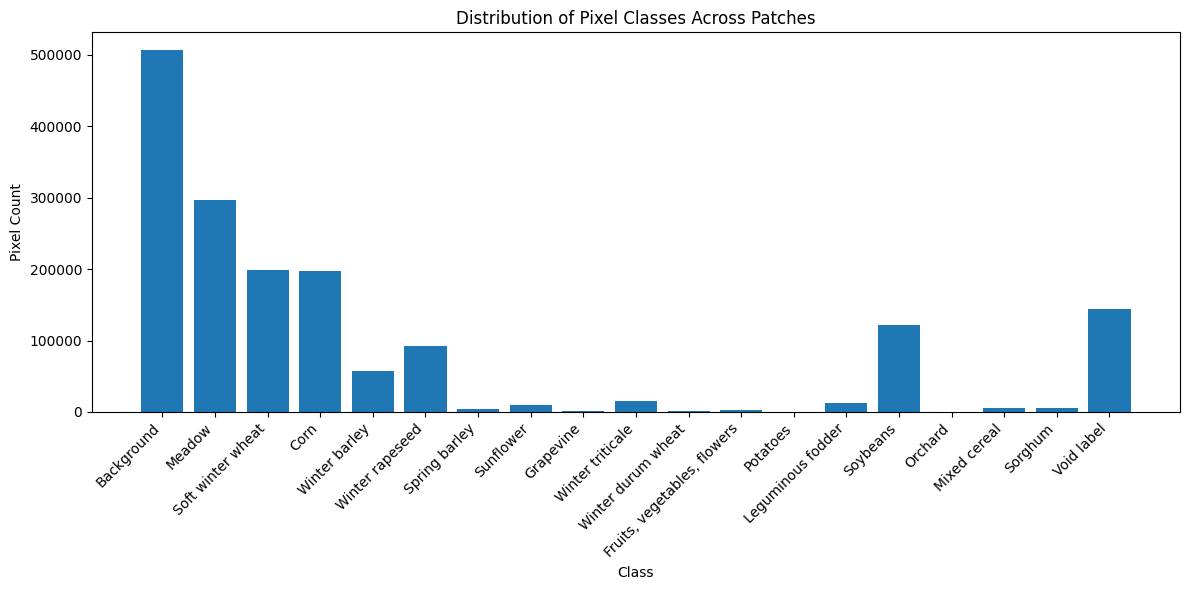

In [14]:


CLASS_NAMES = {
    0: 'Background',
    1: 'Meadow',
    2: 'Soft winter wheat',
    3: 'Corn',
    4: 'Winter barley',
    5: 'Winter rapeseed',
    6: 'Spring barley',
    7: 'Sunflower',
    8: 'Grapevine',
    9: 'Beet',
    10: 'Winter triticale',
    11: 'Winter durum wheat',
    12: 'Fruits, vegetables, flowers',
    13: 'Potatoes',
    14: 'Leguminous fodder',
    15: 'Soybeans',
    16: 'Orchard',
    17: 'Mixed cereal',
    18: 'Sorghum',
    19: 'Void label',
}

def explore_classes(dir_path):
    files = os.listdir(dir_path)

    patch_list = []

    for f in files:
        filepath = os.path.join(dir_path, f)
        data = np.load(filepath)
        patch = pd.Series(data.flatten())
        patch.name = 'class'
        patch.index.name = 'pixel_id'
        patch = patch.reset_index()
        patch['patch'] = int(f.split('.')[0].split('_')[-1])
        patch_list.append(patch)

    patch_df = pd.concat(patch_list, ignore_index=True)

    # Count pixels per class, ordered by label number
    counts = patch_df['class'].value_counts().sort_index()
    labels = [CLASS_NAMES.get(c, str(c)) for c in counts.index]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(labels, counts.values)
    ax.set_xlabel('Class')
    ax.set_ylabel('Pixel Count')
    ax.set_title('Distribution of Pixel Classes Across Patches')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return patch_df

patch_df = explore_classes(anno_folder_path)
patch_df.to_csv('/Users/nithya/Desktop/Personal/solafume/class_df.csv')

Observation: The modal class is background, followed by Meadow. Both are not crops. 
Void label also has a significant share.

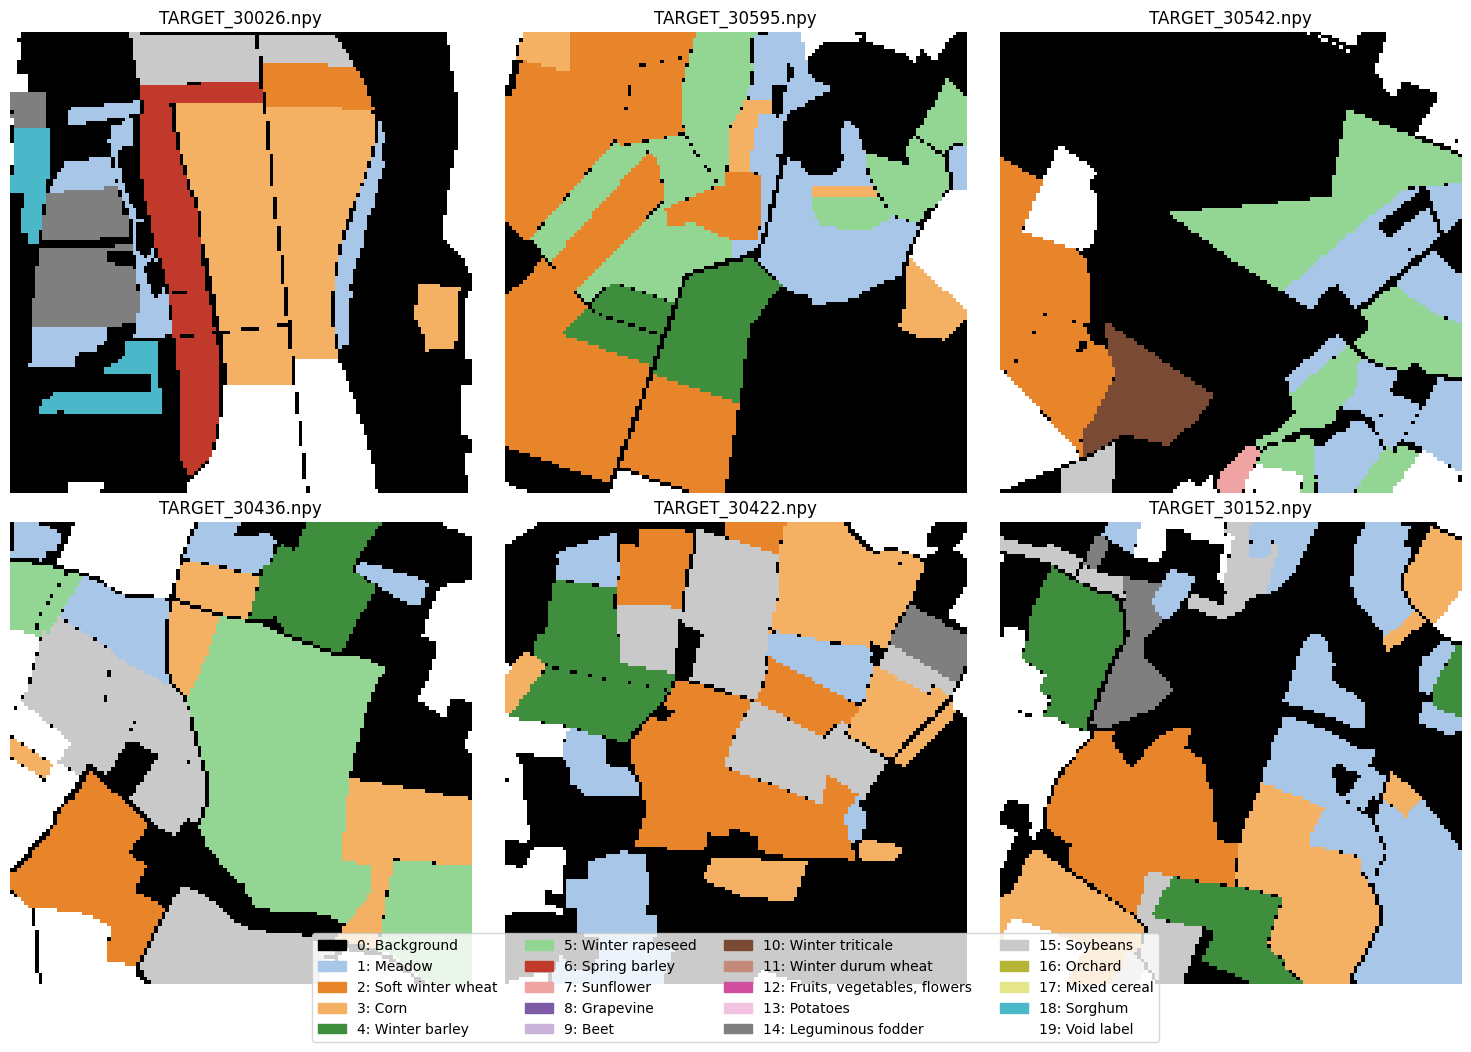

In [5]:


# Class names and colors matching your legend image
CLASS_NAMES = {
    0: 'Background', 1: 'Meadow', 2: 'Soft winter wheat', 3: 'Corn',
    4: 'Winter barley', 5: 'Winter rapeseed', 6: 'Spring barley',
    7: 'Sunflower', 8: 'Grapevine', 9: 'Beet', 10: 'Winter triticale',
    11: 'Winter durum wheat', 12: 'Fruits, vegetables, flowers',
    13: 'Potatoes', 14: 'Leguminous fodder', 15: 'Soybeans',
    16: 'Orchard', 17: 'Mixed cereal', 18: 'Sorghum', 19: 'Void label',
}

CLASS_COLORS = {
    0: '#000000', 1: '#a8c6e8', 2: '#e8842a', 3: '#f4b063',
    4: '#3e8e3e', 5: '#93d693', 6: '#c0392b', 7: '#f0a3a3',
    8: '#7d5ba6', 9: '#c9b3d9', 10: '#7b4a35', 11: '#c48a7a',
    12: '#d24fa0', 13: '#f2c2e0', 14: '#7f7f7f', 15: '#c9c9c9',
    16: '#b5b535', 17: '#e5e58a', 18: '#4bb8c9', 19: '#ffffff',
}

def visualize_patches(dir_path, patch_filenames, cols=3):
    """
    Visualize selected label patches as color-coded images.

    dir_path: folder containing the .npy files
    patch_filenames: list of filenames (e.g. ['patch_1.npy', 'patch_2.npy'])
    cols: number of columns in the plot grid
    """
    n = len(patch_filenames)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)  # flatten in case of single row/col

    # Build a colormap covering all 20 classes (0-19)
    cmap = ListedColormap([CLASS_COLORS[i] for i in range(20)])

    for i, fname in enumerate(patch_filenames):
        filepath = os.path.join(dir_path, fname)
        data = np.load(filepath)
        data = data.squeeze() 

        ax = axes[i]
        im = ax.imshow(data, cmap=cmap, vmin=0, vmax=19)
        ax.set_title(fname)
        ax.axis('off')

    # Hide any unused subplots
    for j in range(n, len(axes)):
        axes[j].axis('off')

    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}')
        for c in range(20)
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=4, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.show()
    
    
files = os.listdir(anno_folder_path)

# Example usage: visualize specific patches by filename
selected_files = files[:6]
visualize_patches(anno_folder_path, selected_files, cols=3)

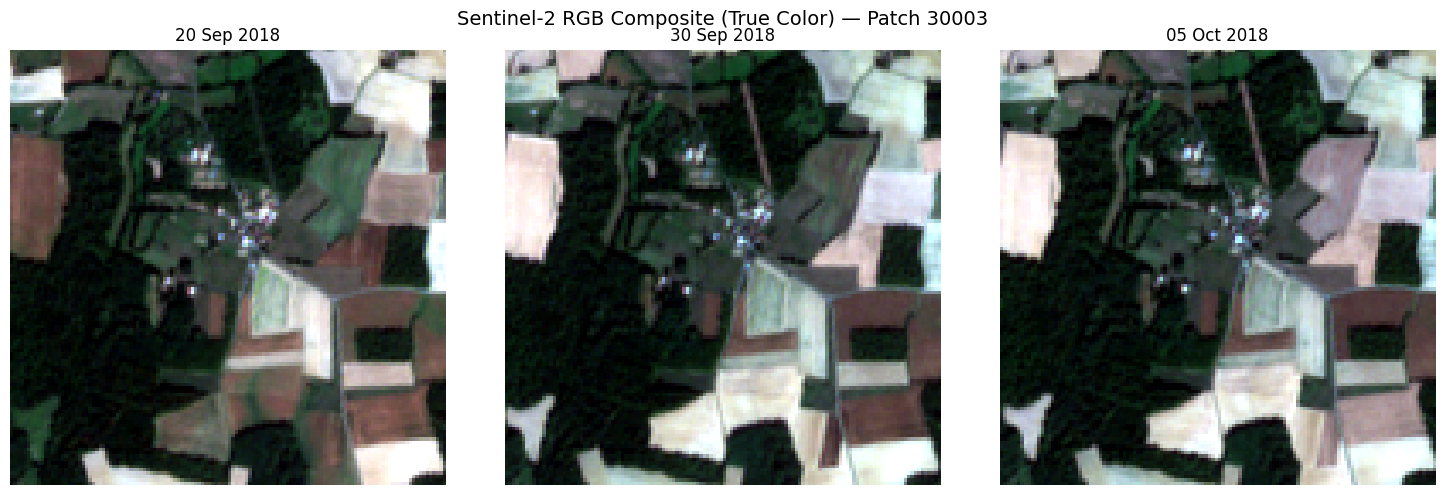

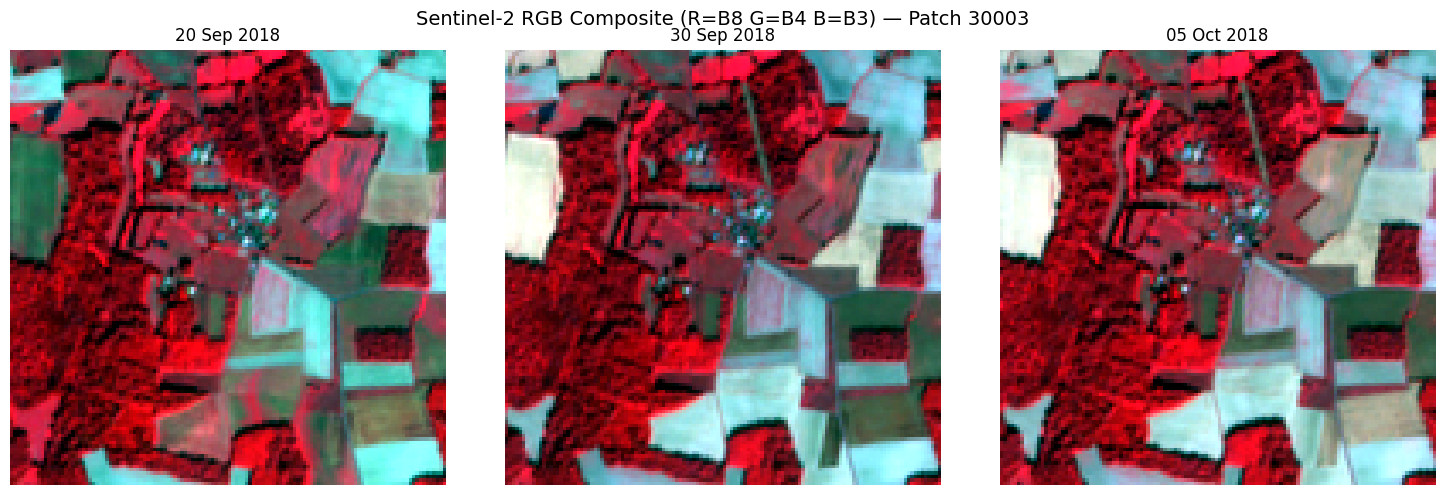

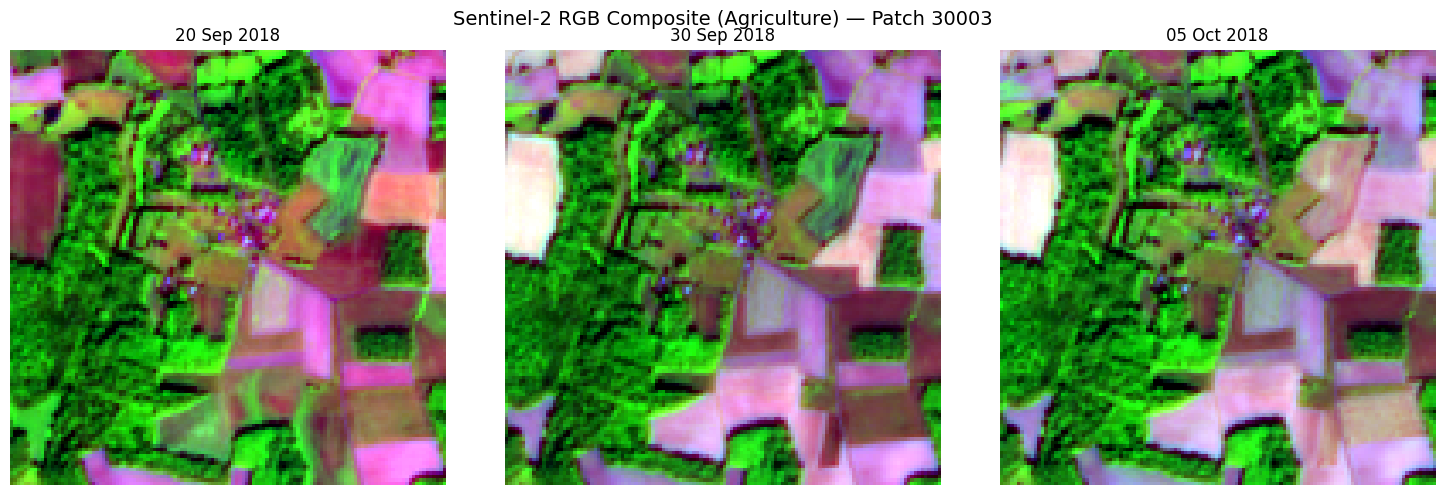

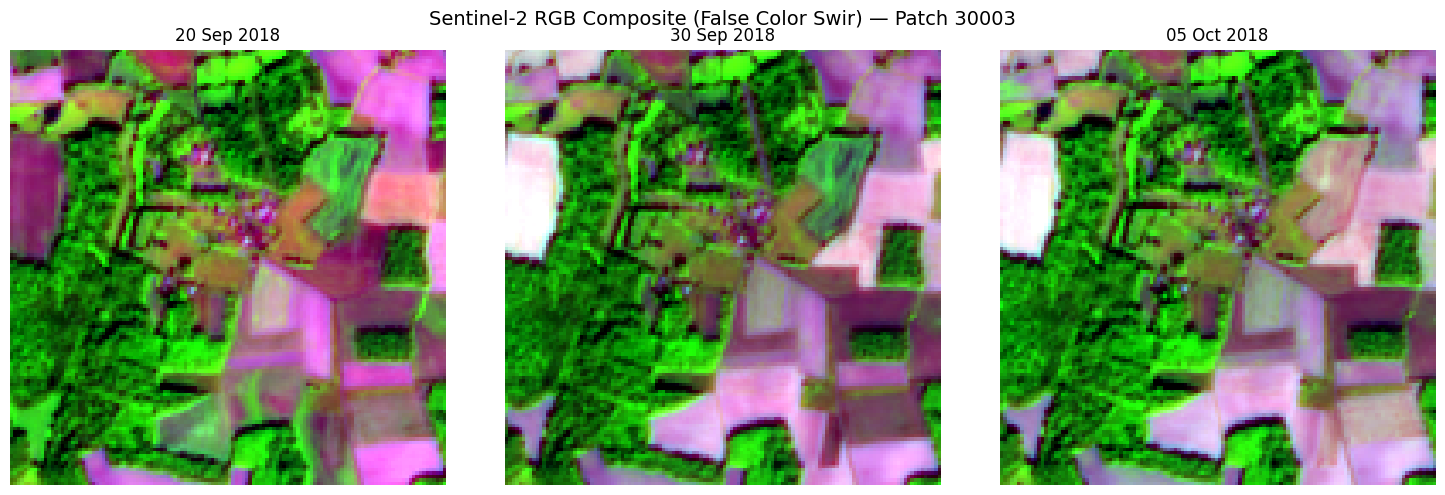

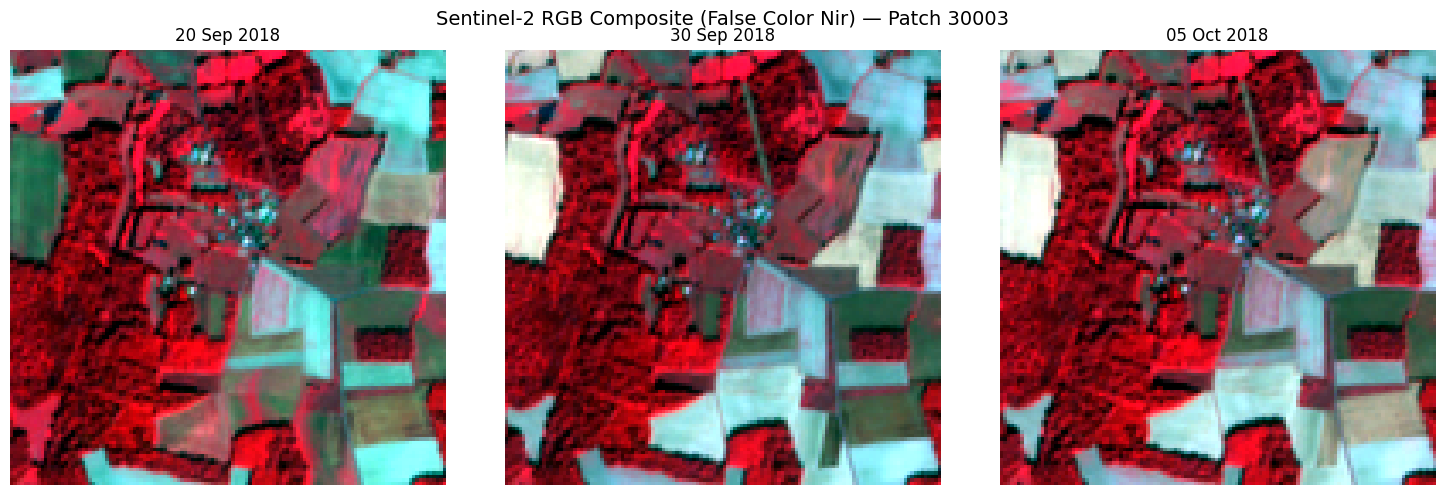

In [8]:


# Reference: band index -> Sentinel-2 band name / common name
BAND_INFO = {
    0: ('B2', 'Blue'),
    1: ('B3', 'Green'),
    2: ('B4', 'Red'),
    3: ('B5', 'Red Edge 1'),
    4: ('B6', 'Red Edge 2'),
    5: ('B7', 'Red Edge 3'),
    6: ('B8', 'Near Infrared'),
    7: ('B8A', 'Narrow Near Infrared'),
    8: ('B11', 'Short-Wave Infrared 1'),
    9: ('B12', 'Short-Wave Infrared 2'),
}

PRESETS = {
    'true_color': (2, 1, 0),
    'false_color_nir': (6, 2, 1),
    'false_color_swir': (8, 6, 2),
    'agriculture': (8, 6, 0),
}


def load_patch_dates(geojson_path):
    """
    Read the metadata.geojson file and build a lookup:
    ID_PATCH -> {observation_index: datetime object}

    The geojson stores dates as YYYYMMDD integers under
    properties['dates-S2'], keyed by observation index (as strings).
    """
    with open(geojson_path) as f:
        meta = json.load(f)

    patch_dates = {}
    for feature in meta['features']:
        props = feature['properties']
        patch_id = props['ID_PATCH']
        dates_raw = props['dates-S2']  # e.g. {"0": 20180920, "1": 20180930, ...}

        dates_parsed = {
            int(obs_idx): datetime.strptime(str(date_int), '%Y%m%d')
            for obs_idx, date_int in dates_raw.items()
        }
        patch_dates[patch_id] = dates_parsed

    return patch_dates


def stretch_band(band, lower_pct=2, upper_pct=98):
    lo, hi = np.percentile(band, (lower_pct, upper_pct))
    if hi <= lo:
        return np.zeros_like(band, dtype=float)
    return np.clip((band - lo) / (hi - lo), 0, 1)


def make_rgb_composite(data, r_band, g_band, b_band, lower_pct=2, upper_pct=98):
    r = stretch_band(data[r_band], lower_pct, upper_pct)
    g = stretch_band(data[g_band], lower_pct, upper_pct)
    b = stretch_band(data[b_band], lower_pct, upper_pct)
    return np.stack([r, g, b], axis=-1)


def visualize_sentinel(data_all, indices, patch_id, patch_dates,
                        bands='true_color', cols=3, lower_pct=2, upper_pct=98):
    """
    Visualize selected Sentinel-2 observations as RGB composites,
    labeled with their acquisition date instead of observation number.

    data_all: array of shape (num_observations, num_bands, height, width)
    indices: list of observation indices to plot, e.g. [0, 5, 12]
    patch_id: the ID_PATCH value for this set of observations, used to
              look up dates in patch_dates
    patch_dates: dict from load_patch_dates(), i.e. ID_PATCH -> {obs_idx: datetime}
    bands: preset name or tuple of 3 band indices, e.g. (6, 2, 1)
    """
    if isinstance(bands, str):
        if bands not in PRESETS:
            raise ValueError(f"Unknown preset '{bands}'. Choose from {list(PRESETS.keys())} "
                              f"or pass a tuple of 3 band indices.")
        r_band, g_band, b_band = PRESETS[bands]
        title_suffix = bands.replace('_', ' ').title()
    else:
        r_band, g_band, b_band = bands
        band_names = [BAND_INFO.get(b, (str(b), str(b)))[0] for b in bands]
        title_suffix = f"R={band_names[0]} G={band_names[1]} B={band_names[2]}"

    dates_for_patch = patch_dates.get(patch_id, {})
        
    n = len(indices)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, obs_idx in enumerate(indices):
        obs_data = data_all[obs_idx]
        rgb = make_rgb_composite(obs_data, r_band, g_band, b_band, lower_pct, upper_pct)

        date_obj = dates_for_patch.get(obs_idx)
        if date_obj is not None:
            title = date_obj.strftime('%d %b %Y')  # e.g. "20 Sep 2018"
        else:
            title = f'Observation {obs_idx} (date unknown)'

        ax = axes[i]
        ax.imshow(rgb)
        ax.set_title(title)
        ax.axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Sentinel-2 RGB Composite ({title_suffix}) — Patch {patch_id}', fontsize=14)
    plt.tight_layout()
    plt.show()

metadata_path = os.path.join(data_path, 'metadata.geojson')
patch_dates = load_patch_dates(metadata_path)


patch_id = 30003
filename = f'S2_{patch_id}.npy'
filepath = os.path.join(s2_folder_path, filename)

# Example usage 1: true color, using a preset
data = np.load(filepath)  # shape (N, 10, H, W)
dates = [0, 1, 2]
visualize_sentinel(data, indices=dates, patch_id=patch_id,
                    patch_dates=patch_dates, bands='true_color', cols=3)

# Example usage 2: custom band combination passed as args (e.g. false color NIR)
visualize_sentinel(data, indices=dates, patch_id=patch_id,
                    patch_dates=patch_dates, bands=(6, 2, 1), cols=3)

# Example usage 3: SWIR-based composite for crop/moisture visualization
visualize_sentinel(data, indices=dates, patch_id=patch_id,
                    patch_dates=patch_dates, bands='agriculture', cols=3)

# Example usage 4: False color SWIR
visualize_sentinel(data, indices=dates, patch_id=patch_id,
                    patch_dates=patch_dates, bands='false_color_swir', cols=3)

# Example usage 3: False color NIR
visualize_sentinel(data, indices=dates, patch_id=patch_id,
                    patch_dates=patch_dates, bands='false_color_nir', cols=3)

In [59]:
import geopandas as gpd
import folium

def interactive_patches_map(geojson_path, patch_ids=None, zoom_start=9):
    """
    Create an interactive Folium map showing patch boundaries over
    Google Satellite imagery.
    """
    gdf = gpd.read_file(geojson_path)

    if patch_ids is not None:
        gdf = gdf[gdf['ID_PATCH'].isin(patch_ids)]

    # Folium requires lat/lon (EPSG:4326)
    gdf_ll = gdf.to_crs(epsg=4326)

    # Center map on the mean centroid of all selected patches
    center = gdf_ll.geometry.unary_union.centroid
    m = folium.Map(location=[center.y, center.x], zoom_start=zoom_start, tiles=None)

    # Add Google Satellite tile layer
    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri World Imagery',
        name='Esri Satellite',
        overlay=False,
        control=True,
    ).add_to(m)

    # Add patch boundaries
    folium.GeoJson(
        gdf_ll,
        name='Patch Boundaries',
        style_function=lambda feature: {
            'fillOpacity': 0,
            'color': 'yellow',
            'weight': 2,
        },
        tooltip=folium.GeoJsonTooltip(fields=['ID_PATCH'], aliases=['Patch ID:'])
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m


# Example usage:
m = interactive_patches_map(metadata_path)
m  # display 

/var/folders/2f/6cz8mp_d2vvfplq8x2_hv17c0000gn/T/ipykernel_1061/3716963537.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf_ll.geometry.unary_union.centroid


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def load_patch_annotation(anno_folder_path, patch_id):
    """
    Load the annotation (class label) file for a given patch_id.

    ADJUST THIS FILENAME PATTERN to match your actual naming convention.
    Currently assumes something like: ANNOTATION_30003.npy
    """
    anno_filename = f'TARGET_{patch_id}.npy'   # <-- adjust as needed
    anno_filepath = os.path.join(anno_folder_path, anno_filename)
    anno = np.load(anno_filepath).squeeze()  # (1,128,128) -> (128,128)
    return anno


def plot_band_timeseries(data, patch_id, patch_dates, anno_folder_path=None,
                          agg='mean', bands=None, subplot_per_band=True,
                          figsize=None, aggregate=True, pixel_alpha=0.15,
                          show_mean_line=True, max_pixels=None,
                          color_by_class=False):
    """
    Plot a time-series line graph for each Sentinel-2 band.

    data: array of shape (num_observations, num_bands, height, width)
    patch_id: ID_PATCH value, used to look up dates in patch_dates
    patch_dates: dict from load_patch_dates()
    agg: 'mean' or 'median' — used only when aggregate=True, or for the
         overlaid summary line when aggregate=False and show_mean_line=True
    bands: list of band indices to plot (default: all 10)
    subplot_per_band: one subplot per band vs. all overlaid on one axis
    aggregate: if True (default), collapse each observation to a single
               summary value per band (original behavior).
               If False, plot every individual pixel's time series as a
               separate faint line, so you can see the full spread/trend
               across the whole patch instead of just the average.
    pixel_alpha: line transparency for individual pixel traces (only used
                 when aggregate=False) — keep this low (e.g. 0.03-0.1)
                 since there can be thousands of overlapping lines
    show_mean_line: when aggregate=False, overlay a bold mean/median line
                     on top of the individual pixel traces for reference
    max_pixels: optional cap on how many pixel traces to plot (randomly
                sampled) when aggregate=False — useful for large patches
                where plotting every pixel (e.g. 128*128=16384 lines) is
                slow or makes the chart too dense to read
    anno_folder_path: folder containing annotation .npy files, required
                       when color_by_class=True
    color_by_class: if True (and aggregate=False), color each pixel's
                     trace by its ground-truth class label instead of a
                     single flat color
    """
    if bands is None:
        bands = list(range(data.shape[1]))

    num_obs = data.shape[0]

    dates_for_patch = patch_dates.get(patch_id, {})
    x_dates = [dates_for_patch.get(i, None) for i in range(num_obs)]
    if any(d is None for d in x_dates):
        print(f"Warning: some observation dates missing for patch {patch_id}, "
              f"using observation index instead.")
        x_dates = list(range(num_obs))

    agg_func = np.mean if agg == 'mean' else np.median

    # Load and flatten annotation if coloring by class
    anno_flat = None
    sample_idx = None
    if color_by_class:
        if aggregate:
            raise ValueError("color_by_class requires aggregate=False "
                              "(per-pixel plotting).")
        if anno_folder_path is None:
            raise ValueError("anno_folder_path must be provided when "
                              "color_by_class=True.")
        anno = load_patch_annotation(anno_folder_path, patch_id)
        anno_flat = anno.flatten()  # shape (H*W,), matches pixel_series columns

    if not aggregate:
        h, w = data.shape[2], data.shape[3]
        pixel_series = {}

        # Determine sampling indices ONCE so all bands + annotation stay aligned
        if max_pixels is not None and max_pixels < h * w:
            rng = np.random.default_rng(seed=42)
            sample_idx = rng.choice(h * w, size=max_pixels, replace=False)

        for b in bands:
            band_data = data[:, b, :, :].reshape(num_obs, h * w)
            if sample_idx is not None:
                band_data = band_data[:, sample_idx]
            pixel_series[b] = band_data

        if color_by_class and sample_idx is not None:
            anno_flat = anno_flat[sample_idx]
    else:
        band_series = {
            b: [agg_func(data[obs, b]) for obs in range(num_obs)]
            for b in bands
        }

    def _plot_pixel_traces(ax, b):
        """Helper: plot pixel traces for band b, colored by class if requested."""
        if color_by_class:
            present_classes = np.unique(anno_flat)
            for c in present_classes:
                mask = anno_flat == c
                if not mask.any():
                    continue
                ax.plot(x_dates, pixel_series[b][:, mask],
                        color=CLASS_COLORS.get(int(c), '#333333'),
                        alpha=pixel_alpha, linewidth=0.8)
            # Build a legend with one entry per class present (not per line)
            handles = [
                plt.Line2D([0], [0], color=CLASS_COLORS.get(int(c), '#333333'),
                           lw=2, label=f'{int(c)}: {CLASS_NAMES.get(int(c), int(c))}')
                for c in present_classes
            ]
            return handles
        else:
            ax.plot(x_dates, pixel_series[b], color='steelblue',
                    alpha=pixel_alpha, linewidth=0.8)
            return None

    if subplot_per_band:
        n = len(bands)
        cols = 1              # CHANGE 1: one chart per row (was 2)
        rows = n
        fig, axes = plt.subplots(rows, cols, figsize=figsize or (12, 3 * rows), sharex=True)
        axes = np.array(axes).reshape(-1)

        legend_handles = None
        for i, b in enumerate(bands):
            band_code, band_name = BAND_INFO.get(b, (str(b), str(b)))
            ax = axes[i]

            if aggregate:
                ax.plot(x_dates, band_series[b], marker='o', markersize=3)
            else:
                handles = _plot_pixel_traces(ax, b)
                if handles is not None:
                    legend_handles = handles
                if show_mean_line:
                    mean_trace = agg_func(pixel_series[b], axis=1)
                    ax.plot(x_dates, mean_trace, color='black', linewidth=2,
                            linestyle='--', label=f'{agg.title()}')

            ax.set_title(f'{band_code} — {band_name}')
            ax.set_ylabel('Reflectance')
            ax.grid(alpha=0.3)

        for j in range(n, len(axes)):
            axes[j].axis('off')

        if color_by_class and legend_handles:
            # CHANGE 2: legend moved to top
            fig.legend(handles=legend_handles, loc='upper center',
                       ncol=4, bbox_to_anchor=(0.5, 1.04))

        fig.suptitle(f'Sentinel-2 Band Time Series — Patch {patch_id}'
                     + ('' if aggregate else ' (all pixels)'), fontsize=14, y=1.08)
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

    else:
        fig, ax = plt.subplots(figsize=figsize or (12, 6))
        legend_handles = None
        for b in bands:
            band_code, band_name = BAND_INFO.get(b, (str(b), str(b)))

            if aggregate:
                ax.plot(x_dates, band_series[b], marker='o', markersize=3,
                        label=f'{band_code} ({band_name})')
            else:
                handles = _plot_pixel_traces(ax, b)
                if handles is not None:
                    legend_handles = handles
                if show_mean_line:
                    mean_trace = agg_func(pixel_series[b], axis=1)
                    ax.plot(x_dates, mean_trace, linewidth=2,
                            label=f'{band_code} ({band_name}) {agg}')

        ax.set_xlabel('Date')
        ax.set_ylabel('Reflectance')
        ax.set_title(f'Sentinel-2 Band Time Series — Patch {patch_id}'
                     + ('' if aggregate else ' (all pixels)'))

        if color_by_class and legend_handles:
            # CHANGE 2 (same fix): legend moved to top
            fig.legend(handles=legend_handles, loc='upper center',
                       ncol=4, bbox_to_anchor=(0.5, 1.08))
        else:
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

        ax.grid(alpha=0.3)
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()


# Example usage:
data = np.load(filepath)   # shape (N, 10, H, W)
plot_band_timeseries(data, patch_id, patch_dates,
                      anno_folder_path=anno_folder_path,
                      aggregate=False, color_by_class=True,
                      max_pixels=500, show_mean_line=False, pixel_alpha=0.5)

In [13]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def get_s2_df(dir_path, patch_dates, patch_id):
    files = os.listdir(dir_path)
    files = [f for f in files if str(patch_id) in f]
    print(files)
    patch_list = []

    for f in tqdm(files):
        patch_id = int(f.split('_')[-1].split('.')[0])
        dates = patch_dates.get(patch_id)
        filepath = os.path.join(dir_path, f)
        data = np.load(filepath)  # shape (no_of_ts, no_of_bands, H, W)

        no_of_ts, no_of_bands, h, w = data.shape
        n_pixels = h * w

        # Flatten spatial dims only: (ts, band, H, W) -> (ts, band, pixel)
        flat = data.reshape(no_of_ts, no_of_bands, n_pixels)

        # Precompute lookup arrays instead of calling .get()/dict lookups per-row
        band_names = np.array([BAND_INFO[b][1] for b in range(no_of_bands)])
        ts_dates = np.array([dates.get(t) for t in range(no_of_ts)])

        # Build index grids for ts, band, pixel — broadcast to match flat's shape
        ts_idx, band_idx, pixel_idx = np.meshgrid(
            np.arange(no_of_ts), np.arange(no_of_bands), np.arange(n_pixels),
            indexing='ij'
        )

        patch_df = pd.DataFrame({
            'pixel_id': pixel_idx.ravel(),
            'band': band_names[band_idx.ravel()],
            'ts': ts_dates[ts_idx.ravel()],
            'value': flat.ravel(),
        })
        patch_df['patch_id'] = patch_id

        patch_list.append(patch_df)

    s2_df = pd.concat(patch_list, ignore_index=True)
    return s2_df


s2_df = get_s2_df(s2_folder_path, patch_dates, '30003')
# s2_df.to_csv('/Users/nithya/Desktop/Personal/solafume/s2_df.csv')

['S2_30003.npy']


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
s2_df = pd.read_csv('/Users/nithya/Desktop/Personal/solafume/s2_df.csv')

In [15]:
merged = s2_df.merge(patch_df, left_on=['patch_id', 'pixel_id'], right_on=['patch', 'pixel_id'], how='left')


(7536640, 7)    pixel_id  band         ts  value  patch_id  class  patch
0         0  Blue 2018-09-20    400     30003     19  30003
1         1  Blue 2018-09-20    425     30003     19  30003
2         2  Blue 2018-09-20    435     30003     19  30003
3         3  Blue 2018-09-20    384     30003     19  30003
4         4  Blue 2018-09-20    364     30003      3  30003


In [16]:
merged[['patch_id', 'pixel_id', 'class', 'band', 'ts', 'value']].head()

,patch_id,pixel_id,class,band,ts,value
0,30003,0,19,Blue,2018-09-20,400
1,30003,1,19,Blue,2018-09-20,425
2,30003,2,19,Blue,2018-09-20,435
3,30003,3,19,Blue,2018-09-20,384
4,30003,4,3,Blue,2018-09-20,364


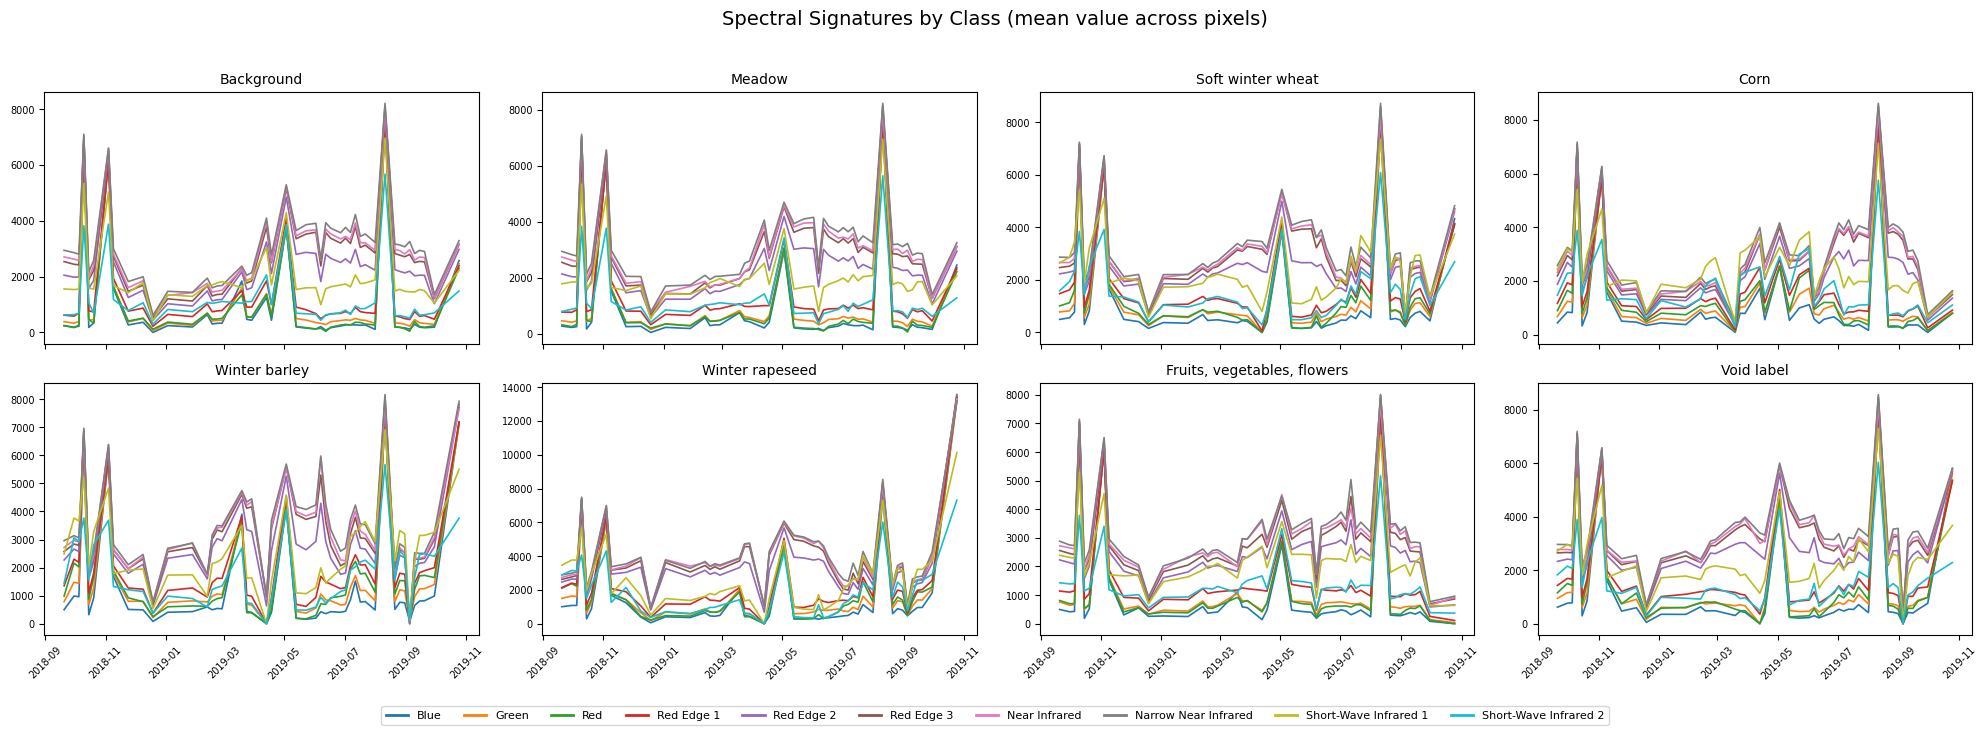

In [20]:
"""
Plot spectral signatures (band vs time) for each land-cover class.

Assumes `df` has columns: patch_id, pixel_id, class, band, ts, value
- Each class gets its own subplot.
- Each subplot has one line per band (mean value across all pixels/patches
  of that class, at each timestamp).
"""

import pandas as pd
import matplotlib.pyplot as plt

def make_spectral_signatures(df):

    # ---------------------------------------------------------------
    # 0) Load your data here if not already in memory
    # df = pd.read_csv("your_file.csv", parse_dates=["ts"])
    # ---------------------------------------------------------------

    df["ts"] = pd.to_datetime(df["ts"])

    # Optional: enforce a sensible band order (wavelength order) instead of
    # alphabetical. Edit this list to match your actual band names.
    band_order = [
        "Coastal", "Blue", "Green", "Red",
        "RedEdge1", "RedEdge2", "RedEdge3", "NIR",
        "NarrowNIR", "WaterVapour", "SWIR1", "SWIR2"
    ]
    bands_present = df["band"].unique().tolist()
    ordered_bands = [b for b in band_order if b in bands_present]
    # append any bands not in the predefined list (keeps script robust)
    ordered_bands += [b for b in bands_present if b not in ordered_bands]

    classes = sorted(df["class"].unique())
    n_classes = len(classes)

    # ---------------------------------------------------------------
    # 1) Aggregate: mean value per class / band / ts (across pixels & patches)
    # ---------------------------------------------------------------
    agg = (
        df.groupby(["class", "band", "ts"])["value"]
        .median()
        .reset_index()
    )

    # ---------------------------------------------------------------
    # 2) Plot: grid of subplots, one per class
    # ---------------------------------------------------------------
    ncols = 4
    nrows = -(-n_classes // ncols)  # ceil division

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True)
    axes = axes.flatten()

    cmap = plt.get_cmap("tab10")
    color_map = {b: cmap(i % 10) for i, b in enumerate(ordered_bands)}

    for ax, cls in zip(axes, classes):
        sub = agg[agg["class"] == cls]
        for band in ordered_bands:
            band_data = sub[sub["band"] == band].sort_values("ts")
            if band_data.empty:
                continue
            ax.plot(
                band_data["ts"], band_data["value"],
                label=band, color=color_map[band], linewidth=1.2
            )
        ax.set_title(f"{CLASS_NAMES.get(cls)}", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    # hide any unused subplots
    for ax in axes[n_classes:]:
        ax.axis("off")

    # single shared legend for all bands
    handles = [
        plt.Line2D([0], [0], color=color_map[b], label=b, linewidth=2)
        for b in ordered_bands
    ]
    fig.legend(
        handles=handles, labels=ordered_bands,
        loc="lower center", ncol=len(ordered_bands), fontsize=8,
        bbox_to_anchor=(0.5, -0.02)
    )

    fig.suptitle("Spectral Signatures by Class (mean value across pixels)", fontsize=14, y=1.01)
    fig.tight_layout(rect=[0, 0.03, 1, 0.99])

    plt.savefig("/Users/nithya/projects/crop-type-classification/outputs/figures/spectral_signatures.png", dpi=150, bbox_inches="tight")
    plt.show()
    
make_spectral_signatures(merged)

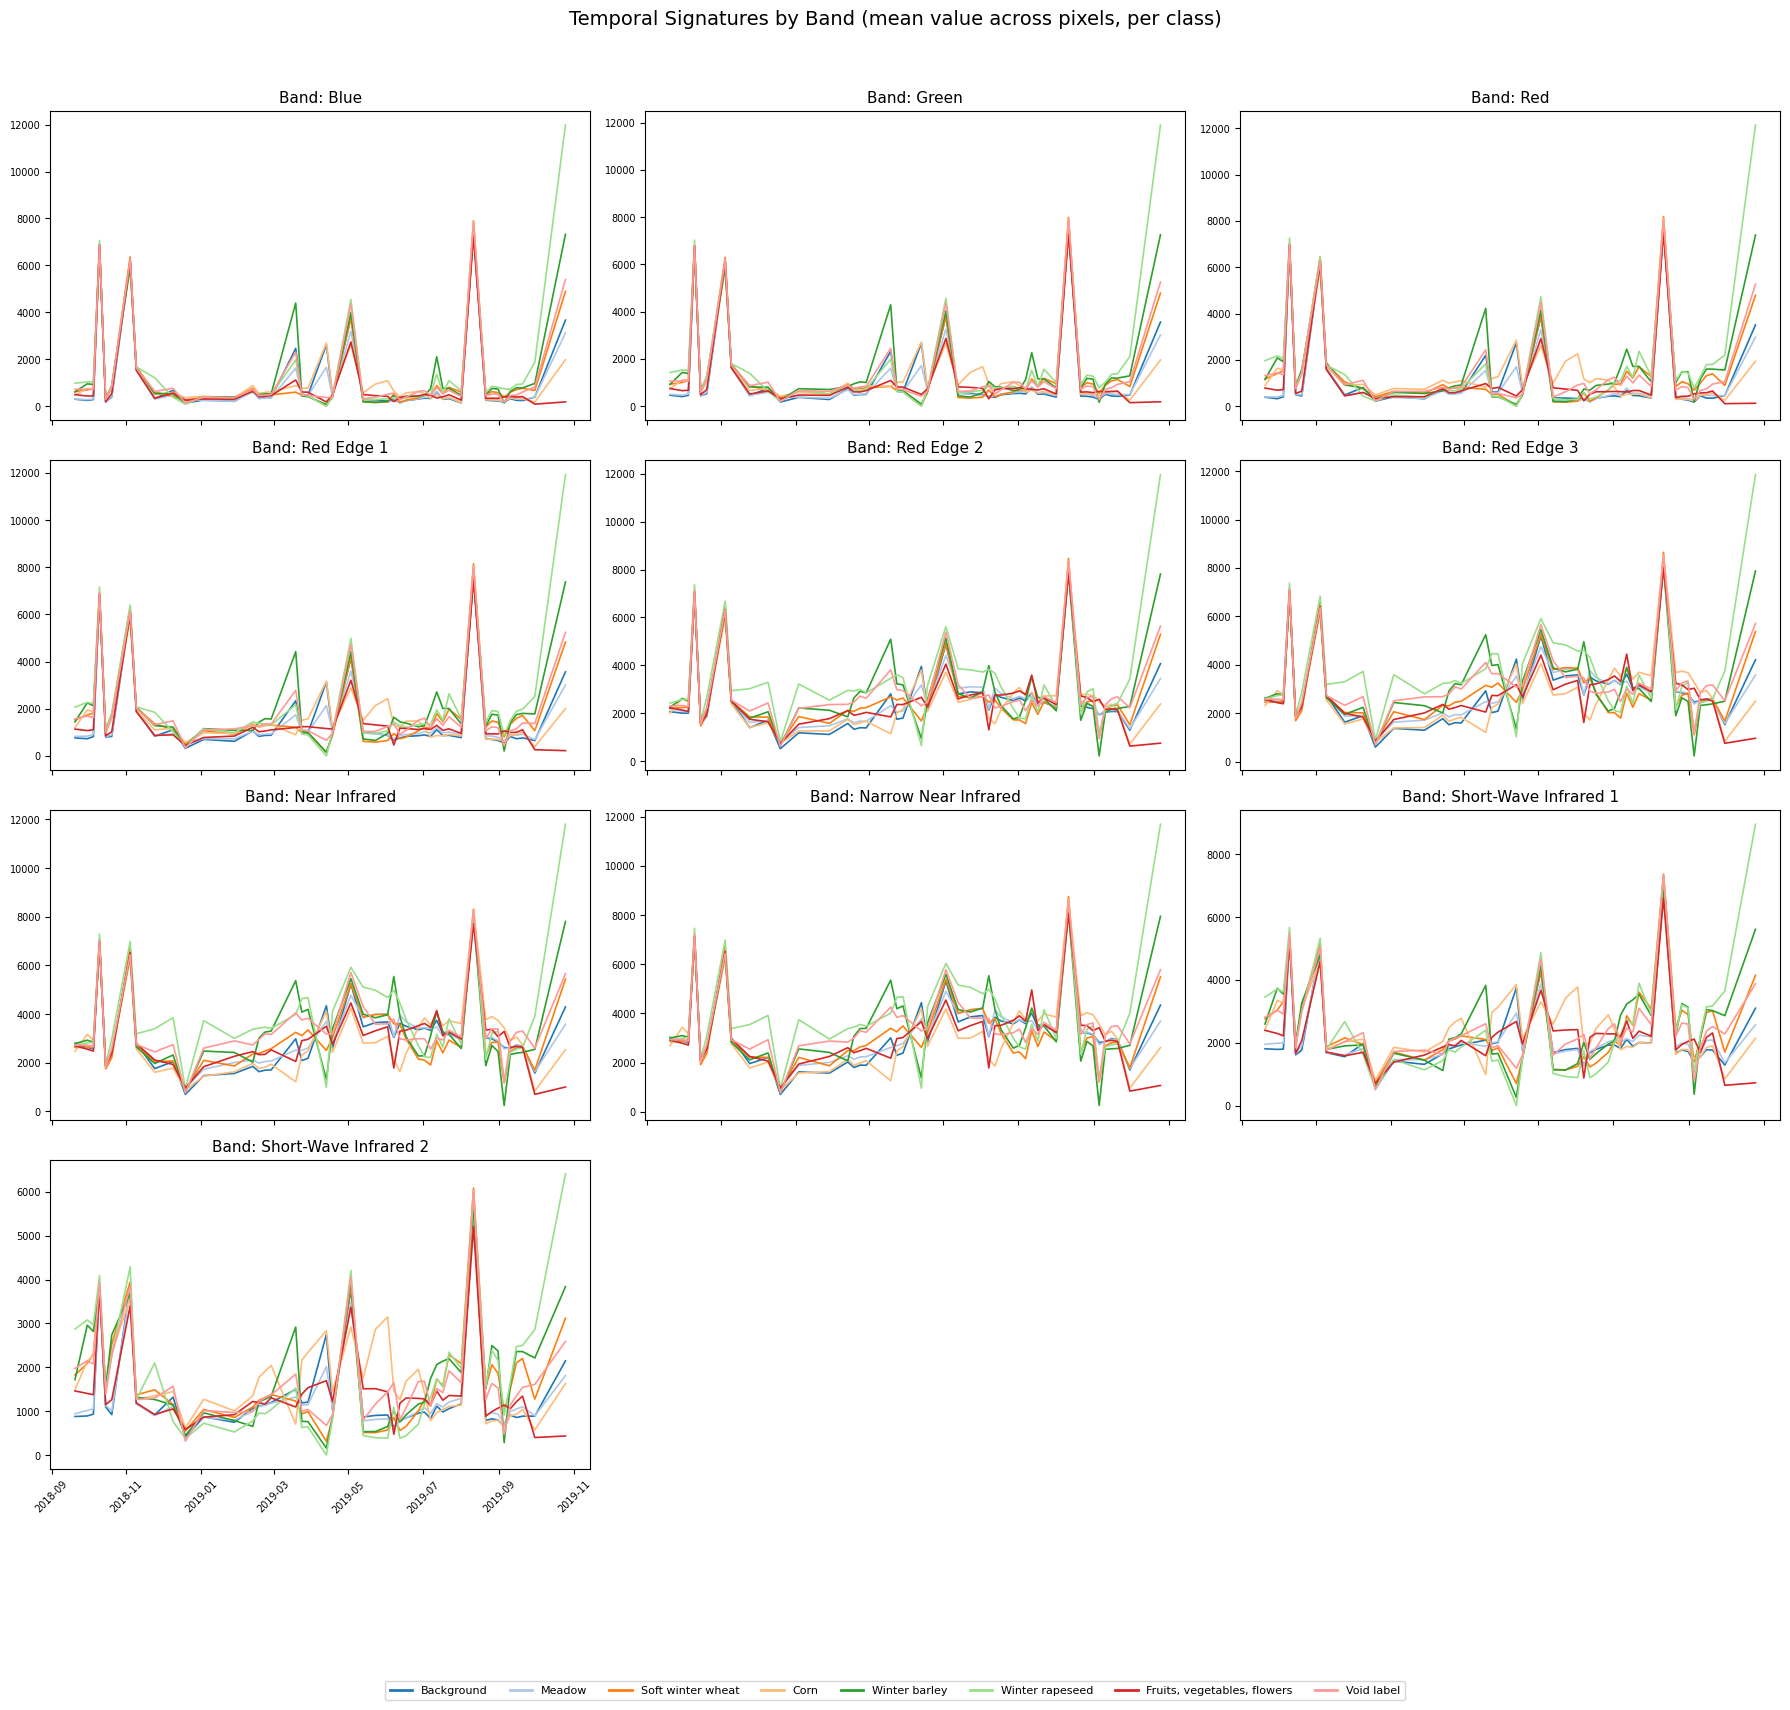

In [24]:
"""
Plot temporal signatures per band, with one line per class.

Assumes `df` has columns: patch_id, pixel_id, class, band, ts, value
- Each band gets its own subplot.
- Each subplot has one line per class (mean value across all pixels/patches
  of that class, at each timestamp).
"""

import pandas as pd
import matplotlib.pyplot as plt


def plot_band_signatures(df):
    # ---------------------------------------------------------------
    # 0) Load your data here if not already in memory
    # df = pd.read_csv("your_file.csv", parse_dates=["ts"])
    # ---------------------------------------------------------------

    df["ts"] = pd.to_datetime(df["ts"])

    # Optional: enforce a sensible band order (wavelength order) instead of
    # alphabetical. Edit this list to match your actual band names.
    band_order = [
        "Coastal", "Blue", "Green", "Red",
        "RedEdge1", "RedEdge2", "RedEdge3", "NIR",
        "NarrowNIR", "WaterVapour", "SWIR1", "SWIR2"
    ]
    bands_present = df["band"].unique().tolist()
    ordered_bands = [b for b in band_order if b in bands_present]
    ordered_bands += [b for b in bands_present if b not in ordered_bands]

    classes = sorted(df["class"].unique())
    n_classes = len(classes)
    n_bands = len(ordered_bands)

    # ---------------------------------------------------------------
    # 1) Aggregate: mean value per band / class / ts (across pixels & patches)
    # ---------------------------------------------------------------
    agg = (
        df.groupby(["band", "class", "ts"])["value"]
        .mean()
        .reset_index()
    )

    # ---------------------------------------------------------------
    # 2) Plot: grid of subplots, one per band
    # ---------------------------------------------------------------
    ncols = 3
    nrows = -(-n_bands // ncols)  # ceil division

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
    axes = axes.flatten()

    # distinct color per class (20 classes -> combine two colormaps for enough
    # distinguishable colors)
    cmap = plt.get_cmap("tab20")
    color_map = {cls: cmap(i % 20) for i, cls in enumerate(classes)}

    for ax, band in zip(axes, ordered_bands):
        sub = agg[agg["band"] == band]
        for cls in classes:
            cls_data = sub[sub["class"] == cls].sort_values("ts")
            if cls_data.empty:
                continue
            ax.plot(
                cls_data["ts"], cls_data["value"],
                label=CLASS_NAMES.get(cls), color=color_map[cls], linewidth=1.2
            )
        ax.set_title(f"Band: {band}", fontsize=11)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    # hide any unused subplots
    for ax in axes[n_bands:]:
        ax.axis("off")

    # single shared legend for all classes
    handles = [
        plt.Line2D([0], [0], color=color_map[c], label=f"{CLASS_NAMES.get(c)}", linewidth=2)
        for c in classes
    ]
    fig.legend(
        handles=handles, loc="lower center", ncol=min(10, n_classes),
        fontsize=8, bbox_to_anchor=(0.5, -0.05)
    )

    fig.suptitle("Temporal Signatures by Band (mean value across pixels, per class)",
                 fontsize=14, y=1.01)
    fig.tight_layout(rect=[0, 0.06, 1, 0.99])

    plt.savefig("/Users/nithya/projects/crop-type-classification/outputs/figures/band_signatures.png", dpi=150, bbox_inches="tight")
    plt.show()
    
plot_band_signatures(merged)

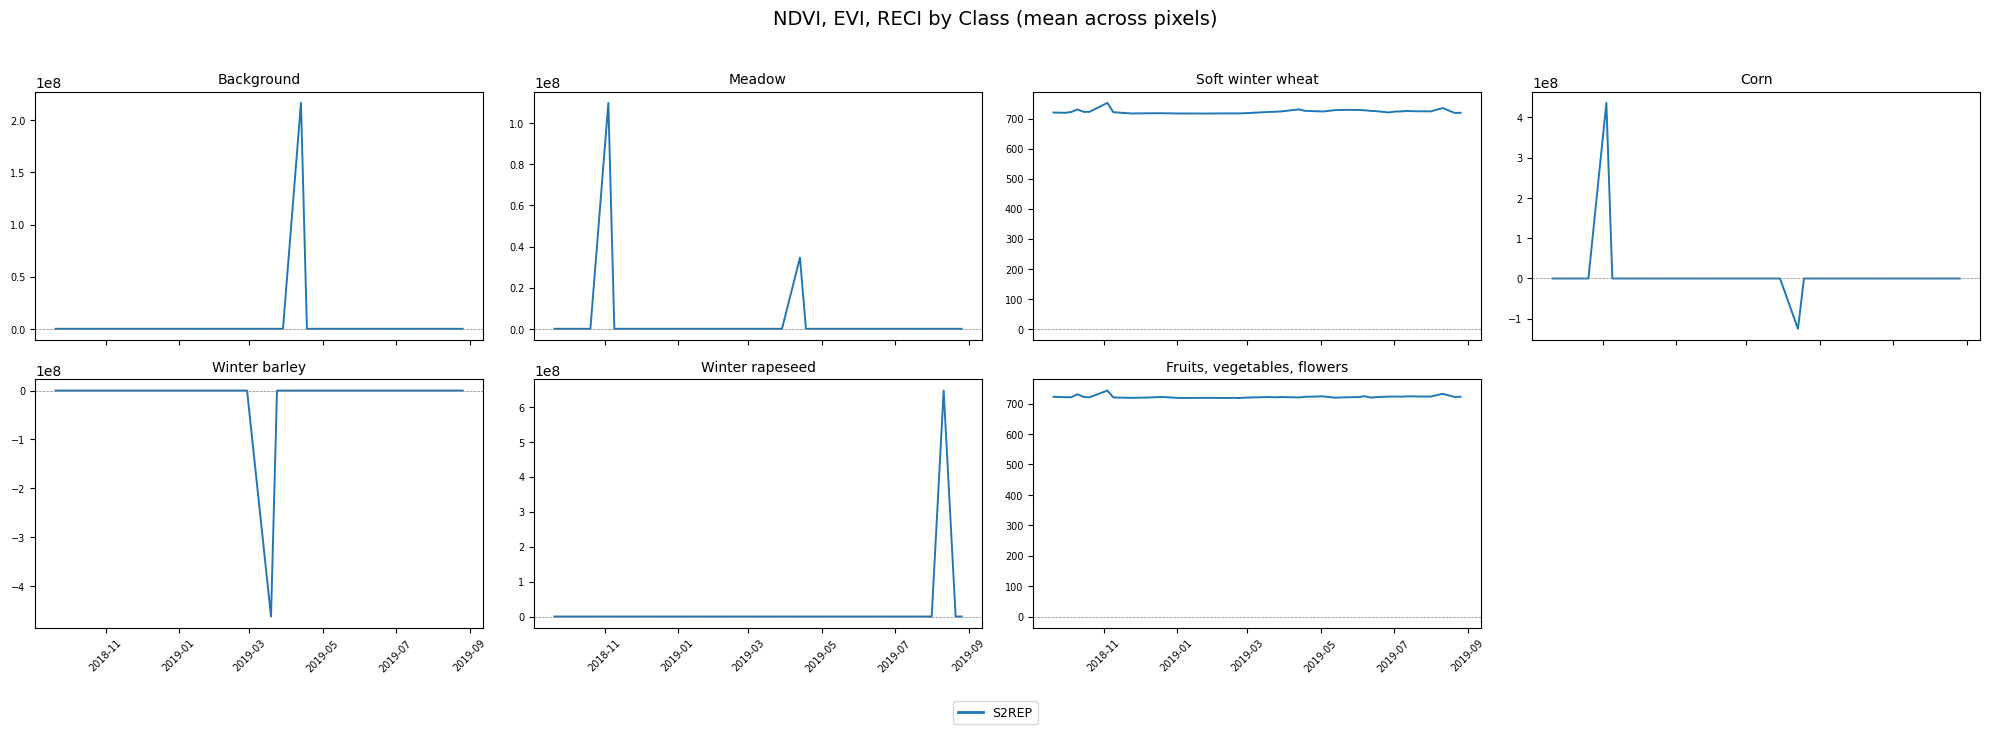

In [78]:
"""
Compute NDVI, EVI, and RECI from Sentinel-2 bands, then plot each index's
time series per class (3 lines per subplot: NDVI, EVI, RECI).

Assumes `df` has columns: patch_id, pixel_id, class, band, ts, value
Requires these bands to be present (edit names below to match your data):
    Blue, Red, NIR, RedEdge1

Formulas used:
    NDVI = (NIR - Red) / (NIR + Red)
    EVI  = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    RECI = (NIR / RedEdge1) - 1
"""

import pandas as pd
import matplotlib.pyplot as plt

def plot_indices(df):

    # ---------------------------------------------------------------
    # 0) Load your data here if not already in memory
    # df = pd.read_csv("your_file.csv", parse_dates=["ts"])
    # ---------------------------------------------------------------
    
    

    df["ts"] = pd.to_datetime(df["ts"])
    
    df = df[df['ts'] <= datetime(2019, 8, 30)]
    df = df[df['class'] != 19] # drop void label. we dont know the class for these. it wont be used for training or validation of the model.

    # ---------------------------------------------------------------
    # 1) EDIT THESE to match your actual band names in df["band"]
    # ---------------------------------------------------------------
    BAND_BLUE = "Blue"
    BAND_GREEN = "Green"
    BAND_RED = "Red"
    BAND_NIR = "Near Infrared"
    BAND_REDEDGE1 = "Red Edge 1"
    BAND_REDEDGE2 = "Red Edge 2"
    BAND_REDEDGE3 = "Red Edge 3"
    
    B2, B3, B4, B5, B6, B7, B8, B11 = "Blue", "Green", "Red", "Red Edge 1", "Red Edge 2", "Red Edge 3", "Near Infrared", "Short-Wave Infrared 1"

    required_bands = [B2, B3, B4, B5, B6, B7, B8, B11]

    required_bands = [BAND_BLUE, BAND_RED, BAND_NIR, BAND_REDEDGE1, BAND_REDEDGE2, BAND_REDEDGE3]
    missing = [b for b in required_bands if b not in df["band"].unique()]
    if missing:
        raise ValueError(
            f"These bands are missing from df['band']: {missing}. "
            f"Available bands: {sorted(df['band'].unique())}. "
            f"Edit BAND_* constants above to match your naming."
        )

    # ---------------------------------------------------------------
    # 2) Pivot to wide format: one column per band, keyed by
    #    patch_id, pixel_id, class, ts
    # ---------------------------------------------------------------
    wide = df.pivot_table(
        index=["patch_id", "pixel_id", "class", "ts"],
        columns="band",
        values="value"
    ).reset_index()

    # ---------------------------------------------------------------
    # 3) Compute indices (per pixel, per ts)
    # ---------------------------------------------------------------
    blue = wide[BAND_BLUE]
    green = wide[BAND_GREEN]
    red = wide[BAND_RED]
    nir = wide[BAND_NIR]
    rededge1 = wide[BAND_REDEDGE1]
    eps = 1e-8
    b2, b3, b4, b5, b6, b7, b8, b11 = wide[B2], wide[B3], wide[B4], wide[B5], wide[B6], wide[B7], wide[B8], wide[B11]
    L = 0.5

    wide["NDVI"] = (nir - red) / (nir + red)
    wide["EVI"] = 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1)
    wide["RECI"] = (nir / rededge1) - 1
    wide["SAVI"] = ((b8 - b4) / (b8 + b4 + L)) * (1 + L)
    wide["NDWI"] = (b8 - b11) / (b8 + b11 + eps)
    wide["NDBI"] = (b11 - b8) / (b11 + b8 + eps)
    wide["NDRE"] = (b8 - b5) / (b8 + b5 + eps)
    wide["GNDVI"] = (b8 - b3) / (b8 + b3 + eps)
    wide["MNDWI"] = (b3 - b11) / (b3 + b11 + eps)
    wide["BR"] = b2 / (b4 + eps)
    wide["SWIR_NIR"] = b11 / (b8 + eps)
    wide["IRECI"] = (b7 - b4) / ((b5 / (b4 + eps)) + eps)
    wide["MTCI"] = (b6 - b5) / (b5 - b4 + eps)
    wide["MACRI"] = ((b5 - b4) - 0.2 * (b5 - b3)) * (b5 / (b4 + eps))
    wide["S2REP"] = 705 + 35 * (((b4 + b7) / 2 - b5) / (b6 - b5 + eps))

    indices = [
#         "NDVI", 
#         "EVI", 
#     "GNDVI",
#     "MNDWI",
#         "SAVI", 
#         "NDWI", 
#         "NDBI", 
#         "NDRE", 
#         "RECI", 
#         "BR", 
#               "SWIR_NIR", 
#         "IRECI", 
#         "MTCI", 
#         "MACRI", 
        "S2REP"
             ]
    

    # ---------------------------------------------------------------
    # 4) Aggregate: mean index value per class / ts (across pixels & patches)
    # ---------------------------------------------------------------
    agg = (
        wide.groupby(["class", "ts"])[indices]
        .mean()
        .reset_index()
    )

    classes = sorted(agg["class"].unique())
    n_classes = len(classes)

    # ---------------------------------------------------------------
    # 5) Plot: grid of subplots, one per class, 3 lines each (NDVI/EVI/RECI)
    # ---------------------------------------------------------------
    ncols = 4
    nrows = -(-n_classes // ncols)  # ceil division

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True)
    axes = axes.flatten()

    cmap = plt.get_cmap("tab10")
    color_map = {idx: cmap(i % 10) for i, idx in enumerate(indices)}
    
    for ax, cls in zip(axes, classes):
        sub = agg[agg["class"] == cls].sort_values("ts")
        for idx in indices:
            ax.plot(sub["ts"], sub[idx], label=idx, color=color_map[idx], linewidth=1.4)
        ax.set_title(f"{CLASS_NAMES.get(cls)}", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")

    for ax in axes[n_classes:]:
        ax.axis("off")

    handles = [plt.Line2D([0], [0], color=color_map[i], label=i, linewidth=2) for i in indices]
    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("NDVI, EVI, RECI by Class (mean across pixels)", fontsize=14, y=1.01)
    fig.tight_layout(rect=[0, 0.04, 1, 0.99])

    plt.savefig("/Users/nithya/projects/crop-type-classification/outputs/figures/vegetation_indices_by_class.png", dpi=150, bbox_inches="tight")
    plt.show()
    
plot_indices(merged)

Based on visual interpretation of the spectral signatures and index patterns of different classes, the following features will be used as inputs:

1. EVI (min, max, area under the curve)
2. RECI (area under the curve, std, max)
3. BR (no of spikes, max value)
4. NDVI (area under the curve, month of max value (as a cyclic variable))
5. NDBI (min)
6. NDRE (max, area_under_curve)
7. SWIR_NIR (slope, days from max to min, month of max value (as a cyclic variable), std)

We use only sept to aug data, since that is one crop season in France, our AOI. If we include sep-nov of 2019, that would be the next season. it may pollute the data since the farmer may grow some other crop in the new season. 

In [70]:
class_df = pd.read_csv('/Users/nithya/Desktop/Personal/solafume/class_df.csv')

In [72]:
class_df['class'].value_counts().sort_index()

class
0     506141
1     296576
2     199108
3     196704
4      57381
5      92912
6       3472
7       9579
8       1345
10     15215
11       725
12      3229
13       158
14     12634
15    121560
16        75
17      5220
18      5047
19    144087
Name: count, dtype: int64